# SupplyPrescript

# Sprint 4 - Exploratory Data Analysis

## Objective

The purpose of this notebook is to understand the relationships between different logistics factors and shipment disruptions through visual analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/processed/cleaned_logistics_dataset.csv")

df.head()

,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Year,Month,Day,DayOfWeek
0,7,4,1,4,5930.83,197.42,2.43,5.0,2,0.865,41.39,1,2025,10,16,4
1,7,7,1,0,14285.36,237.24,2.30,7.5,4,0.592,40.92,1,2024,4,24,6
2,5,4,1,2,11113.91,427.42,1.78,5.6,3,0.673,11.54,0,2024,1,26,0
3,1,3,1,1,9180.55,170.66,3.20,0.8,2,0.832,53.13,1,2024,10,8,5
4,1,8,0,2,2762.27,434.96,2.77,1.9,1,0.741,0.50,1,2024,9,7,2


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 5000
Columns : 16


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Origin_Port                5000 non-null   int64  
 1   Destination_Port           5000 non-null   int64  
 2   Transport_Mode             5000 non-null   int64  
 3   Product_Category           5000 non-null   int64  
 4   Distance_km                5000 non-null   float64
 5   Weight_MT                  5000 non-null   float64
 6   Fuel_Price_Index           5000 non-null   float64
 7   Geopolitical_Risk_Score    5000 non-null   float64
 8   Weather_Condition          5000 non-null   int64  
 9   Carrier_Reliability_Score  5000 non-null   float64
 10  Lead_Time_Days             5000 non-null   float64
 11  Disruption_Occurred        5000 non-null   int64  
 12  Year                       5000 non-null   int64  
 13  Month                      5000 non-null   int64  
 14  Day

In [5]:
correlation = df.corr(numeric_only=True)

correlation

,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Year,Month,Day,DayOfWeek
Origin_Port,1.000000,-0.144039,0.006615,0.009728,0.006427,0.013597,0.023788,-0.001750,-0.020459,-0.018337,0.016444,0.007196,-0.009197,-0.019123,-0.026814,0.011090
Destination_Port,-0.144039,1.000000,-0.026712,0.003638,-0.012729,0.016081,-0.008865,-0.009720,0.004264,-0.025269,0.008331,0.009442,-0.005999,-0.001011,0.017493,-0.003496
Transport_Mode,0.006615,-0.026712,1.000000,0.028510,-0.014833,-0.019828,0.000156,0.007504,-0.010445,-0.010634,0.405049,-0.005257,0.005951,-0.009008,-0.004414,-0.008493
Product_Category,0.009728,0.003638,0.028510,1.000000,-0.005923,-0.003325,-0.008828,-0.000280,0.006315,-0.030108,0.019352,0.030244,-0.009051,0.016341,-0.034607,0.002560
Distance_km,0.006427,-0.012729,-0.014833,-0.005923,1.000000,-0.007016,-0.009501,0.028623,-0.009098,-0.011321,0.335665,0.009905,-0.005282,-0.012842,0.004774,-0.018616
Weight_MT,0.013597,0.016081,-0.019828,-0.003325,-0.007016,1.000000,-0.022806,-0.000546,-0.003479,0.009955,-0.005838,0.012733,0.009766,0.009445,0.004826,0.002192
Fuel_Price_Index,0.023788,-0.008865,0.000156,-0.008828,-0.009501,-0.022806,1.000000,0.006807,0.000657,-0.027467,-0.010256,0.003709,0.000598,0.008607,0.006834,0.011230
Geopolitical_Risk_Score,-0.001750,-0.009720,0.007504,-0.000280,0.028623,-0.000546,0.006807,1.000000,0.002750,0.010409,0.087650,0.225159,0.023661,0.019159,-0.001599,0.010232
Weather_Condition,-0.020459,0.004264,-0.010445,0.006315,-0.009098,-0.003479,0.000657,0.002750,1.000000,-0.012955,0.105945,0.231527,0.000822,-0.004435,-0.020129,-0.001308
Carrier_Reliability_Score,-0.018337,-0.025269,-0.010634,-0.030108,-0.011321,0.009955,-0.027467,0.010409,-0.012955,1.000000,-0.008773,-0.078927,0.002391,0.018684,-0.005131,-0.024387


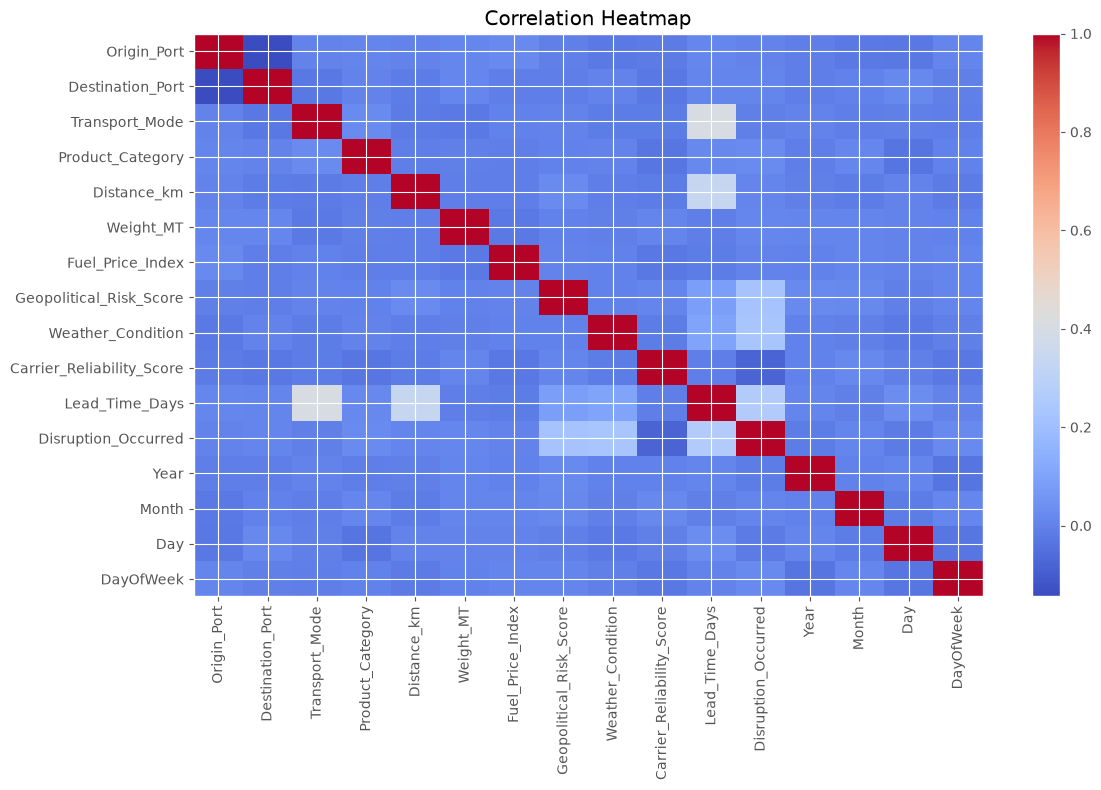

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

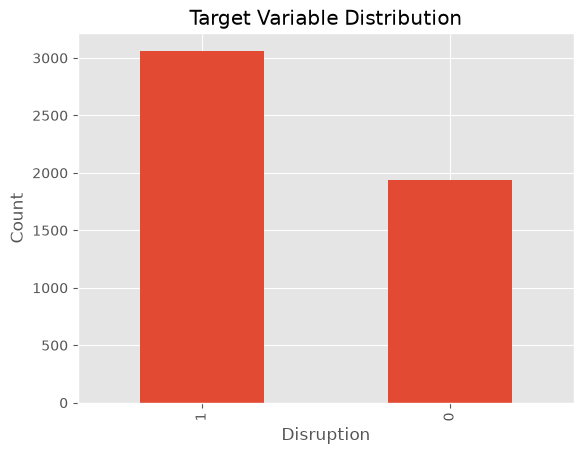

In [7]:
df["Disruption_Occurred"].value_counts().plot(
    kind="bar"
)

plt.title("Target Variable Distribution")
plt.xlabel("Disruption")
plt.ylabel("Count")

plt.show()

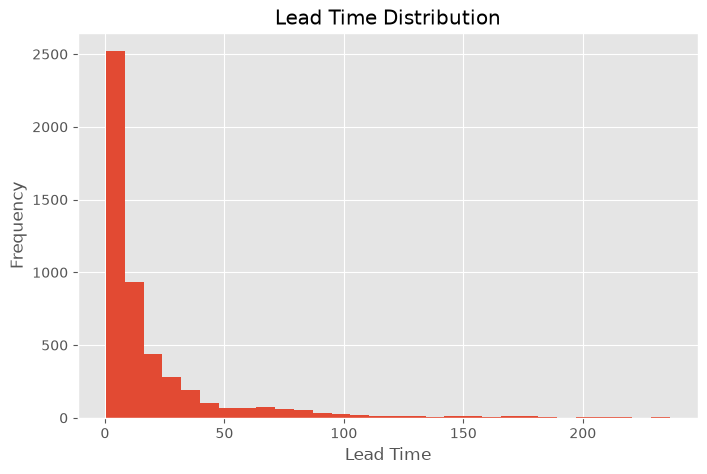

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df["Lead_Time_Days"], bins=30)

plt.title("Lead Time Distribution")

plt.xlabel("Lead Time")

plt.ylabel("Frequency")

plt.show()

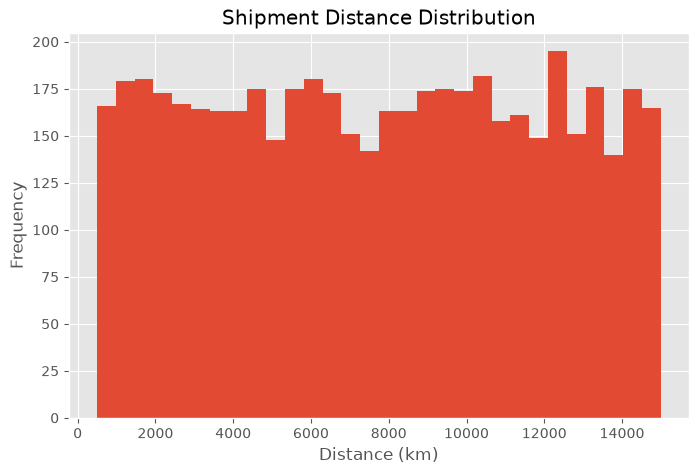

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["Distance_km"], bins=30)

plt.title("Shipment Distance Distribution")

plt.xlabel("Distance (km)")

plt.ylabel("Frequency")

plt.show()

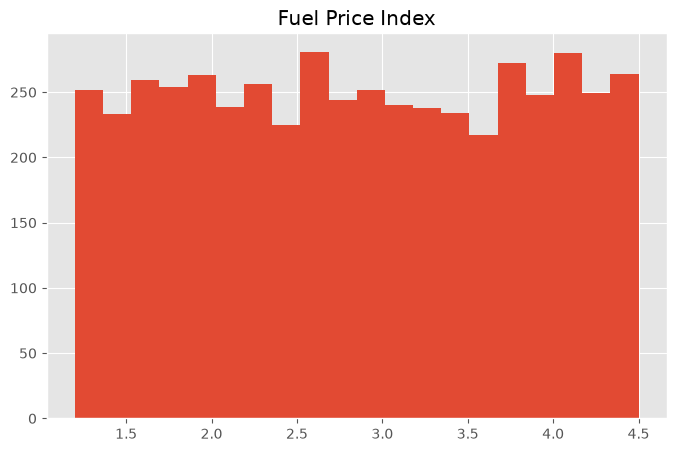

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df["Fuel_Price_Index"], bins=20)

plt.title("Fuel Price Index")

plt.show()

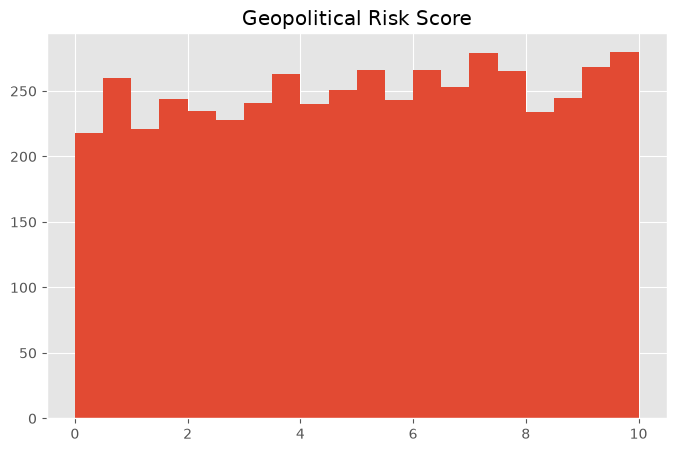

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df["Geopolitical_Risk_Score"], bins=20)

plt.title("Geopolitical Risk Score")

plt.show()

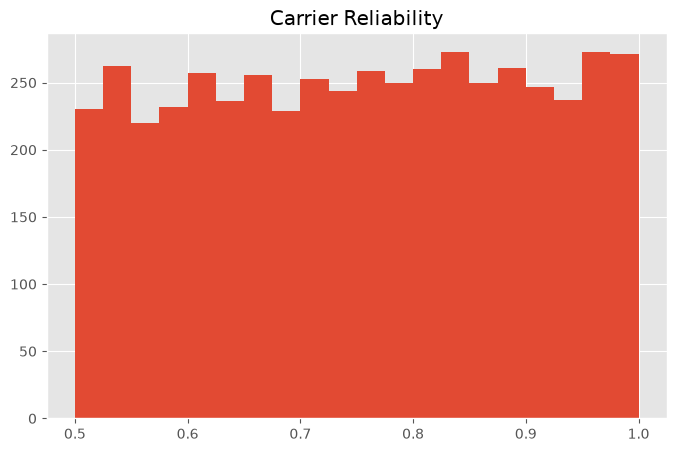

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["Carrier_Reliability_Score"], bins=20)

plt.title("Carrier Reliability")

plt.show()

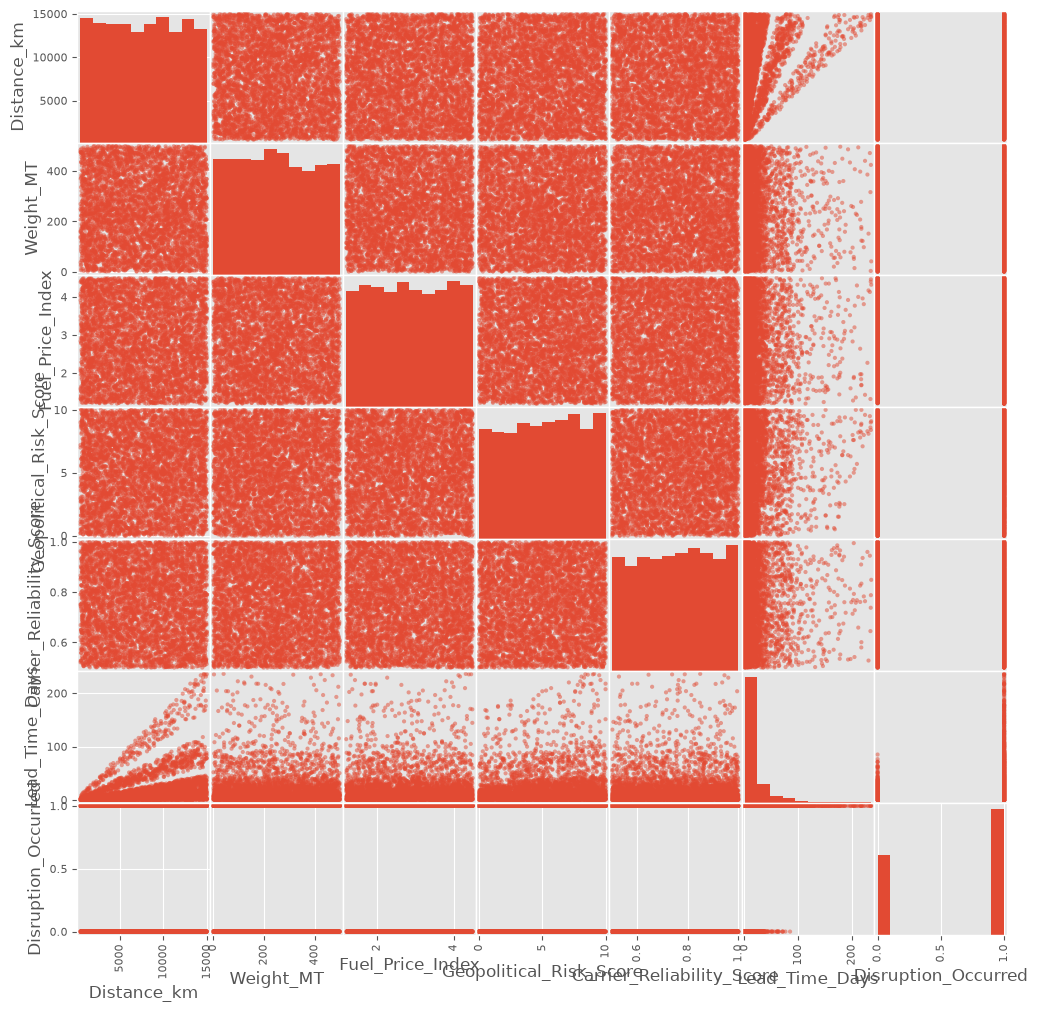

In [13]:
numeric_cols = [
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Carrier_Reliability_Score",
    "Lead_Time_Days",
    "Disruption_Occurred"
]

pd.plotting.scatter_matrix(
    df[numeric_cols],
    figsize=(12, 12)
)

plt.show()

# Business Insights

## Key Findings

- Distribution of disruptions is slightly imbalanced.
- Lead time shows significant variation.
- Fuel price index remains within a moderate range.
- Geopolitical risk may influence shipment disruptions.
- Carrier reliability is expected to be negatively related to disruptions.
- Correlation analysis helps identify the strongest predictive variables.